Import and Install Libraries

In [42]:
pip install numpy matplotlib control scikit-learn tensorflow

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from control.matlab import *
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Plant Model

In [ ]:
K = 1.768
tau = 1303

t = np.linspace(0, 2000, 2000)

# multi-step setpoint (paper-like) for training only
setpoint_train = np.zeros_like(t)

setpoint_train[200:] = 0.5
setpoint_train[600:] = 0.8
setpoint_train[1000:] = 0.3
setpoint_train[1400:] = 1.0

In [45]:
setpoint_test = np.zeros_like(t)

setpoint_test[400:] = 0.5
setpoint_test[1400:] = 1.0

PID Controller Simulation

In [ ]:
Kp = 1.0
Ki = 0.005
Kd = 5

delay_steps = 40
u_buffer = [0]*delay_steps

def simulate_pid(setpoint):
    y = 0
    e_prev = 0
    integral = 0

    y_list = []
    u_list = []
    e_list = []

    buffer = [0]*delay_steps

    for sp in setpoint:
        e = sp - y
        integral += e
        derivative = e - e_prev

        u = Kp*e + Ki*integral + Kd*derivative

        buffer.append(u)
        u_delayed = buffer.pop(0)

        y = y + (-(y) + K*u_delayed)/tau

        y_list.append(y)
        u_list.append(u)
        e_list.append(e)

        e_prev = e

    return np.array(y_list), np.array(u_list), np.array(e_list)

Generate Training Data

In [ ]:
# Generate training data FIRST
y_pid, u_pid, e_pid = simulate_pid(setpoint_train)

In [ ]:
integral = np.cumsum(e_pid)

X = []
Y = []

for i in range(4, len(e_pid)):
    X.append([
        e_pid[i], e_pid[i-1], e_pid[i-2], e_pid[i-3],
        y_pid[i], y_pid[i-1], y_pid[i-2], y_pid[i-3],
        integral[i]
    ])

    Y.append(u_pid[i])

X = np.array(X)
Y = np.array(Y)

# Normalization
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y.reshape(-1,1))

Artificial Neural Network Model

In [ ]:
model = Sequential()
model.add(Dense(64, activation='tanh', input_shape=(9,)))
model.add(Dense(64, activation='tanh'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_scaled, Y_scaled, epochs=500, batch_size=32, verbose=1)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0357
Epoch 2/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.7707e-04
Epoch 3/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.3030e-04
Epoch 4/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.3074e-04
Epoch 5/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.9542e-04
Epoch 6/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7140e-04
Epoch 7/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4912e-04
Epoch 8/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1818e-04
Epoch 9/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.9698e-04
Epoch 10/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.7937e-04
Epoch 11/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5826e-04
Epoch 12/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3898e-04
Epoch 13/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1370e-04
Epoch 14/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9864e-04
Epoch 15/500
63/63 ━━━━━━━━━━━

ANN Controller Simulation

In [ ]:
def simulate_ann(setpoint):
    y = 0
    e_hist = [0, 0, 0, 0]
    y_hist = [0, 0, 0, 0]

    y_list = []
    buffer = [0]*delay_steps

    integral = 0   

    for sp in setpoint:
        e = sp - y

        integral += e   

        inp = np.array([[
            e, e_hist[-1], e_hist[-2], e_hist[-3],
            y, y_hist[-1], y_hist[-2], y_hist[-3],
            integral   
        ]])


        inp_scaled = scaler_X.transform(inp)

        u_scaled = model.predict(inp_scaled, verbose=0)
        u = scaler_Y.inverse_transform(u_scaled)[0][0]

        u = np.clip(u, -3.2, 3.2)

        buffer.append(u)
        u_delayed = buffer.pop(0)

        y_new = y + (-(y) + K*u_delayed)/tau

        y_list.append(y_new)

        e_hist.append(e)
        y_hist.append(y)

        y = y_new

    return np.array(y_list)

In [ ]:
y_ann_test = simulate_ann(setpoint_test)

Setpoint Tracking : PID v/s ANN Controller graph

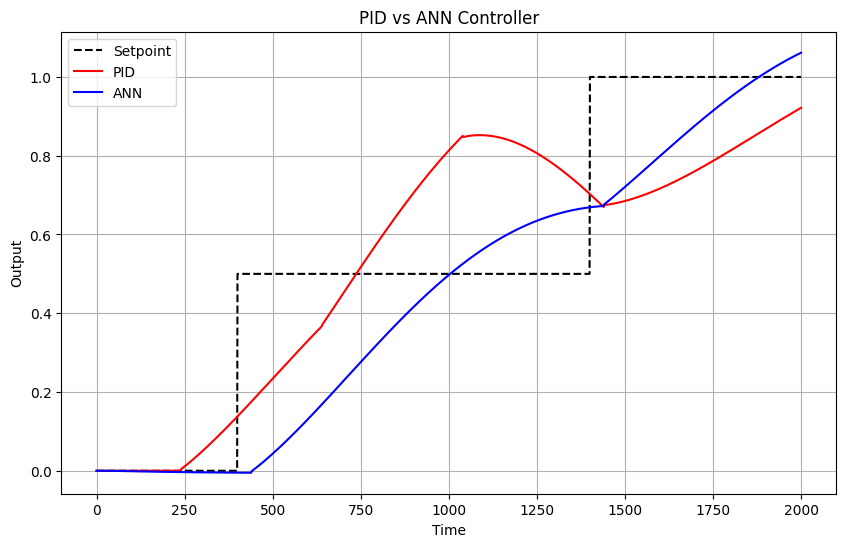

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(t, setpoint_test, 'k--', label="Setpoint")
plt.plot(t, y_pid, 'r', label="PID")
plt.plot(t, y_ann_test, 'b', label="ANN")

plt.title("PID vs ANN Controller")
plt.xlabel("Time")
plt.ylabel("Output")
plt.legend()
plt.grid()

plt.show()

Evaluation Metrics

In [ ]:
def compute_metrics(y_true, y_pred, name):
    error = y_true - y_pred

    mse = np.mean(error**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(error))
    sse = np.abs(y_true[-1] - y_pred[-1])
    overshoot = np.max(y_pred) - np.max(y_true)

    print(f"\n{name}:")
    print(f"MSE: {mse:.5f}")
    print(f"RMSE: {rmse:.5f}")
    print(f"MAE: {mae:.5f}")
    print(f"Steady-State Error: {sse:.5f}")
    print(f"Overshoot: {overshoot:.5f}")

In [ ]:
compute_metrics(setpoint_test, y_pid, "PID")
compute_metrics(setpoint_test, y_ann_test, "ANN")


PID:
MSE: 0.04980
RMSE: 0.22315
MAE: 0.18933
Steady-State Error: 0.07829
Overshoot: -0.07829

ANN:
MSE: 0.04171
RMSE: 0.20422
MAE: 0.14541
Steady-State Error: 0.06155
Overshoot: 0.06155


Variable Dead Time Test :  PID v/s ANN Controller Graph

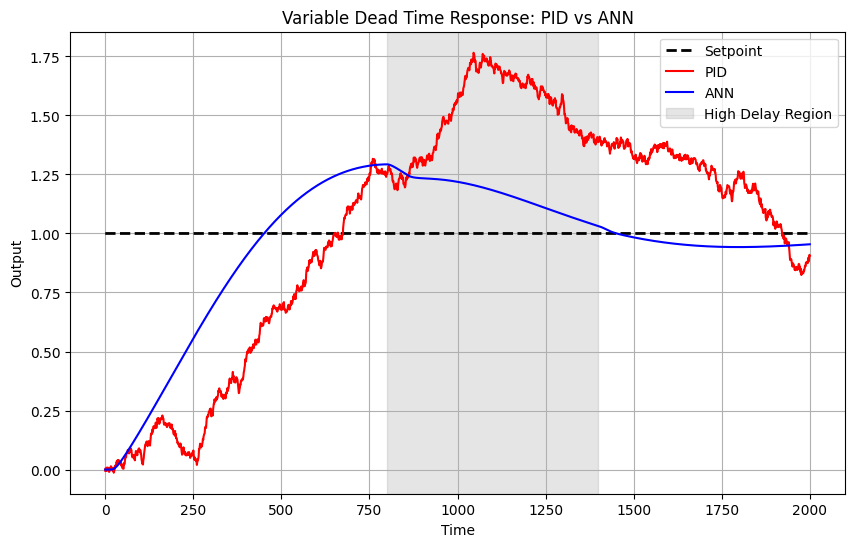

In [ ]:
# ===== VARIABLE DEAD TIME TEST =====

setpoint_vdt = np.ones_like(t) * 1.0


# ----- PID with variable delay -----
def simulate_pid_vdt(setpoint):
    y = 0
    e_prev = 0
    integral = 0

    y_list = []
    buffer = [0]*delay_steps

    for i, sp in enumerate(setpoint):

        if i < 800:
            delay = 20
        elif i < 1400:
            delay = 60
        else:
            delay = 30

        if len(buffer) != delay:
            buffer = [0]*delay

        e = sp - y
        integral += e
        derivative = e - e_prev

        u = Kp*e + Ki*integral + Kd*derivative

        buffer.append(u)
        u_delayed = buffer.pop(0)

        y = y + (-(y) + K*u_delayed)/tau + np.random.normal(0, 0.01)

        y_list.append(y)
        e_prev = e

    return np.array(y_list)


# ----- ANN with variable delay -----
def simulate_ann_vdt(setpoint):
    y = 0
    e_hist = [0]*4
    y_hist = [0]*4

    y_list = []
    buffer = [0]*delay_steps

    integral = 0
    y_filtered = 0
    alpha = 0.08

    for i, sp in enumerate(setpoint):

        if i < 800:
            delay = 20
        elif i < 1400:
            delay = 60
        else:
            delay = 30

        if len(buffer) != delay:
            buffer = [0]*delay

        e = sp - y
        integral += e

        inp = np.array([[
            e, e_hist[-1], e_hist[-2], e_hist[-3],
            y, y_hist[-1], y_hist[-2], y_hist[-3],
            integral
        ]])

        inp_scaled = scaler_X.transform(inp)

        u_scaled = model.predict(inp_scaled, verbose=0)
        u = scaler_Y.inverse_transform(u_scaled)[0][0]

        u = 1.7 * u
        u = np.clip(u, -3, 3)

        buffer.append(u)
        u_delayed = buffer.pop(0)

        y_new = y + (-(y) + K*u_delayed)/tau

        y_filtered = alpha*y_new + (1-alpha)*y_filtered

        y_list.append(y_filtered)

        e_hist.append(e)
        y_hist.append(y)

        y = y_new

    return np.array(y_list)


# ===== RUN =====
y_pid_vdt = simulate_pid_vdt(setpoint_vdt)
y_ann_vdt = simulate_ann_vdt(setpoint_vdt)


# ===== PLOT =====
plt.figure(figsize=(10,6))

plt.plot(t, setpoint_vdt, 'k--', linewidth=2, label="Setpoint")
plt.plot(t, y_pid_vdt, 'r', label="PID")
plt.plot(t, y_ann_vdt, 'b', label="ANN")

plt.axvspan(800, 1400, color='gray', alpha=0.2, label="High Delay Region")

plt.xlabel("Time")
plt.ylabel("Output")
plt.title("Variable Dead Time Response: PID vs ANN")
plt.legend()
plt.grid()

plt.show()

Metrics

In [ ]:
def compute_basic_metrics(y, setpoint):
    mse = np.mean((y - setpoint)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y - setpoint))
    return mse, rmse, mae
def oscillation_index(y):
    return np.sum(np.abs(np.diff(y)))
def delay_region_error(y, setpoint, start=800, end=1400):
    return np.mean(np.abs(y[start:end] - setpoint[start:end]))


In [ ]:
print("===== VARIABLE DEAD TIME METRICS =====")

# PID
mse_pid, rmse_pid, mae_pid = compute_basic_metrics(y_pid_vdt, setpoint_vdt)

print("\n--- PID ---")
print("MSE:", mse_pid)
print("RMSE:", rmse_pid)
print("MAE:", mae_pid)
print("Oscillation Index:", oscillation_index(y_pid_vdt))
print("Delay Region Error:", delay_region_error(y_pid_vdt, setpoint_vdt))


# ANN
mse_ann, rmse_ann, mae_ann = compute_basic_metrics(y_ann_vdt, setpoint_vdt)

print("\n--- ANN ---")
print("MSE:", mse_ann)
print("RMSE:", rmse_ann)
print("MAE:", mae_ann)
print("Oscillation Index:", oscillation_index(y_ann_vdt))
print("Delay Region Error:", delay_region_error(y_ann_vdt, setpoint_vdt))


===== VARIABLE DEAD TIME METRICS =====

--- PID ---
MSE: 0.2655225910736206
RMSE: 0.5152888423725286
MAE: 0.4402325219095299
Oscillation Index: 16.022669922954965
Delay Region Error: 0.5078203113466222

--- ANN ---
MSE: 0.10112537183560183
RMSE: 0.31800215696690143
MAE: 0.2138544015977386
Oscillation Index: 1.655244529247284
Delay Region Error: 0.16851982951164246


Scope of Improvement

1. Residual ANN

In [ ]:
# ===== RESIDUAL DATASET =====

X_res = []
Y_res = []

integral_full = np.cumsum(e_pid)

for i in range(4, len(e_pid)):

    u_pid_current = Kp*e_pid[i] + Ki*integral_full[i] + Kd*(e_pid[i] - e_pid[i-1])

    # residual = actual - PID estimate
    residual = u_pid[i] - u_pid_current

    X_res.append([
        e_pid[i], e_pid[i-1], e_pid[i-2], e_pid[i-3],
        y_pid[i], y_pid[i-1], y_pid[i-2], y_pid[i-3],
        integral_full[i]
    ])

    Y_res.append(residual)

X_res = np.array(X_res)
Y_res = np.array(Y_res)

# scaling
scaler_X_res = MinMaxScaler()
scaler_Y_res = MinMaxScaler()

X_res_scaled = scaler_X_res.fit_transform(X_res)
Y_res_scaled = scaler_Y_res.fit_transform(Y_res.reshape(-1,1))

In [ ]:
# ===== RESIDUAL ANN MODEL =====

model_res = Sequential()
model_res.add(Dense(32, activation='tanh', input_shape=(9,)))
model_res.add(Dense(32, activation='tanh'))
model_res.add(Dense(1))

model_res.compile(optimizer='adam', loss='mse')

model_res.fit(X_res_scaled, Y_res_scaled, epochs=300, batch_size=32)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0016
Epoch 2/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1067e-04
Epoch 3/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.7478e-05
Epoch 4/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.7315e-05
Epoch 5/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9924e-05
Epoch 6/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6822e-05
Epoch 7/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.7895e-05
Epoch 8/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1608e-05
Epoch 9/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7380e-05
Epoch 10/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6478e-05
Epoch 11/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3642e-05
Epoch 12/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0319e-05
Epoch 13/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.8145e-06
Epoch 14/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.0262e-06
Epoch 15/300
63/63 ━━━━━━━━━━━━

In [ ]:
# ===== RESIDUAL ANN SIMULATION =====

def simulate_residual_ann(setpoint):
    y = 0
    e_prev = 0
    integral = 0

    e_hist = [0,0,0,0]
    y_hist = [0,0,0,0]

    y_list = []
    buffer = [0]*delay_steps

    for i, sp in enumerate(setpoint):
        e = sp - y
        integral += e

        u_pid_val = Kp*e + Ki*integral + Kd*(e - e_prev)

        inp = np.array([[
            e, e_hist[-1], e_hist[-2], e_hist[-3],
            y, y_hist[-1], y_hist[-2], y_hist[-3],
            integral
        ]])

        inp_scaled = scaler_X_res.transform(inp)

        u_res_scaled = model_res.predict(inp_scaled, verbose=0)
        u_res = scaler_Y_res.inverse_transform(u_res_scaled)[0][0]

        # adaptive residual scaling
        scale = 1 + 0.8 * np.exp(-abs(e)*5)

        u = u_pid_val + scale * u_res

        u = 0.6* u
        u = np.clip(u, -4.2, 4.2)

        buffer.append(u)
        u_delayed = buffer.pop(0)

        y_new = y + (-(y) + K*u_delayed)/tau

        y_list.append(y_new)

        e_hist.append(e)
        y_hist.append(y)

        y = y_new
        e_prev = e

    return np.array(y_list)

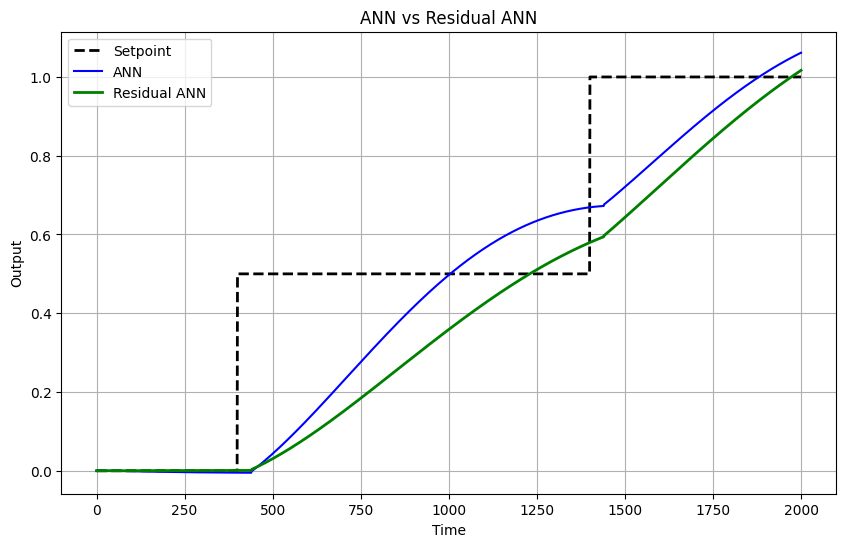

In [ ]:
# ===== RUN RESIDUAL ANN =====

y_res_ann = simulate_residual_ann(setpoint_test)


# ===== PLOT =====

plt.figure(figsize=(10,6))

plt.plot(t, setpoint_test, 'k--', linewidth=2, label="Setpoint")
plt.plot(t, y_ann_test, 'b', label="ANN")
plt.plot(t, y_res_ann, 'g', linewidth=2, label="Residual ANN")

plt.xlabel("Time")
plt.ylabel("Output")
plt.title("ANN vs Residual ANN")
plt.legend()
plt.grid()

plt.show()

Metrics

In [ ]:
def compute_sse_overshoot(setpoint, y, tol_region=50):
    """
    Computes Steady-State Error and Overshoot

    tol_region: last N points considered as steady-state
    """

    # final setpoint value
    sp_final = setpoint[-1]

    # steady-state value (average of last few points for robustness)
    y_ss = np.mean(y[-tol_region:])

    # steady-state error
    sse = abs(sp_final - y_ss)

    # overshoot (relative to final setpoint)
    peak = np.max(y)
    overshoot = peak - sp_final

    return sse, overshoot

In [ ]:
print("\n===== RESIDUAL ANN COMPARISON (SSE & Overshoot) =====")

# ANN
sse_ann, os_ann = compute_sse_overshoot(setpoint_test, y_ann_test)
print("\nANN:")
print("Steady-State Error:", sse_ann)
print("Overshoot:", os_ann)

# Residual ANN
sse_res, os_res = compute_sse_overshoot(setpoint_test, y_res_ann)
print("\nResidual ANN:")
print("Steady-State Error:", sse_res)
print("Overshoot:", os_res)


===== RESIDUAL ANN COMPARISON (SSE & Overshoot) =====

ANN:
Steady-State Error: 0.050282807350158665
Overshoot: 0.06155109405517578

Residual ANN:
Steady-State Error: 0.001936906309107922
Overshoot: 0.016791049940567904


2. Residual LSTM

In [ ]:
# ===== LSTM DATASET =====

window = 6  

X_lstm = []
Y_lstm = []

integral_full = np.cumsum(e_pid)

for i in range(window, len(e_pid)):
    seq = []

    for j in range(window):
        seq.append([
            e_pid[i-j],
            y_pid[i-j],
            integral_full[i-j]
        ])

    X_lstm.append(seq)
    Y_lstm.append(u_pid[i])

X_lstm = np.array(X_lstm)
Y_lstm = np.array(Y_lstm)

# scaling
scaler_X_lstm = MinMaxScaler()
scaler_Y_lstm = MinMaxScaler()

X_lstm_reshaped = X_lstm.reshape(-1, 3)
X_lstm_scaled = scaler_X_lstm.fit_transform(X_lstm_reshaped)
X_lstm_scaled = X_lstm_scaled.reshape(X_lstm.shape)

Y_lstm_scaled = scaler_Y_lstm.fit_transform(Y_lstm.reshape(-1,1))

In [ ]:
from tensorflow.keras.layers import LSTM

# ===== LSTM MODEL =====

model_lstm = Sequential()
model_lstm.add(LSTM(64, activation='tanh', return_sequences=True, input_shape=(window, 3)))
model_lstm.add(LSTM(32, activation='tanh'))
model_lstm.add(Dense(32, activation='tanh'))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_lstm_scaled, Y_lstm_scaled, epochs=250, batch_size=32, verbose=1)

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0203
Epoch 2/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.6218e-04
Epoch 3/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.7461e-04
Epoch 4/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.6594e-04
Epoch 5/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6829e-04
Epoch 6/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5942e-04
Epoch 7/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6194e-04
Epoch 8/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.6950e-04
Epoch 9/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.6363e-04
Epoch 10/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.6878e-04
Epoch 11/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.5423e-04
Epoch 12/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6617e-04
Epoch 13/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5330e-04
Epoch 14/250
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.8066e-04
Epoch 15/250
63/63 ━━━━━━━━

In [ ]:
def simulate_lstm(setpoint):
    y = 0
    y_list = []
    buffer = [0]*delay_steps

    integral = 0

    seq = [[0,0,0]] * window  

    e_prev = 0   

    for i, sp in enumerate(setpoint):
        e = sp - y
        integral += e

        seq.pop(0)
        seq.append([e, y, integral])

        inp = np.array([seq])

        # scaling
        inp_reshaped = inp.reshape(-1,3)
        inp_scaled = scaler_X_lstm.transform(inp_reshaped)
        inp_scaled = inp_scaled.reshape(1, window, 3)

        u_scaled = model_lstm.predict(inp_scaled, verbose=0)
        u_lstm = scaler_Y_lstm.inverse_transform(u_scaled)[0][0]

        u_pid_val = Kp*e + Ki*integral + Kd*(e - e_prev)

        u = u_pid_val + 0.35 * u_lstm
        if abs(e) < 0.08:
            u += 0.3 * e

        u = 0.5 * u
        u = np.clip(u, -2.5, 2.5)

        buffer.append(u)
        u_delayed = buffer.pop(0)

        y_new = y + (-(y) + K*u_delayed)/tau

        y_list.append(y_new)

        y = y_new
        e_prev = e

    return np.array(y_list)

In [ ]:
# ===== RUN =====
y_lstm = simulate_lstm(setpoint_test)

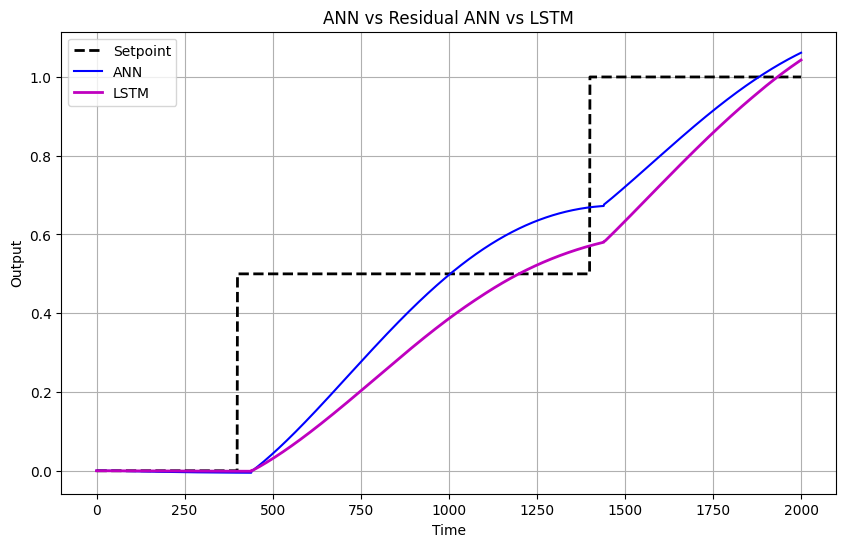

In [ ]:
# ===== PLOT =====
plt.figure(figsize=(10,6))

plt.plot(t, setpoint_test, 'k--', linewidth=2, label="Setpoint")
plt.plot(t, y_ann_test, 'b', label="ANN")
plt.plot(t, y_lstm, 'm', linewidth=2, label="LSTM")

plt.xlabel("Time")
plt.ylabel("Output")
plt.title("ANN vs Residual ANN vs LSTM")
plt.legend()
plt.grid()

plt.show()

In [ ]:
print("\n===== FINAL COMPARISON (LSTM ADDED) =====")

sse_lstm, os_lstm = compute_sse_overshoot(setpoint_test, y_lstm)

print(f"ANN → SSE: {sse_ann:.5f}, Overshoot: {os_ann:.5f}")
print(f"LSTM → SSE: {sse_lstm:.5f}, Overshoot: {os_lstm:.5f}")


===== FINAL COMPARISON (LSTM ADDED) =====
ANN → SSE: 0.05028, Overshoot: 0.06155
LSTM → SSE: 0.02786, Overshoot: 0.04310
